# Predicting Irrigation Need 

#### Dataset Description
The dataset for this competition (both train and test) was generated from a deep learning model trained on the Irrigation Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

#### Files
* train.csv - the training set, with Irrigation_Need as target
* test.csv - the test set, used to predict the category for Irrigation_Need
* sample_submission.csv - a sample submission file in the correct format

https://www.kaggle.com/competitions/playground-series-s6e4/overview

In [62]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

In [63]:
base_dir = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))
base_dir

'd:\\Codes\\Artificial_Intelligence\\Machine_Learning\\Machine-Learning-With-Scikit-Learn\\Projects'

In [64]:
# Reading training and test datasets
print('Reading the train and test datasets .....')
train_df = pd.read_csv(fr'{base_dir}/Datasets/predicting_irrigation_need/train.csv')
test_df = pd.read_csv(fr'{base_dir}/Datasets/predicting_irrigation_need/test.csv')
print('Successfully read the train and test datasets.')

Reading the train and test datasets .....
Successfully read the train and test datasets.


In [65]:
print(f'Size of train dataset: {train_df.shape}')
print(f'Size of test dataset: {test_df.shape}')

Size of train dataset: (630000, 21)
Size of test dataset: (270000, 20)


In [66]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [67]:
train_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [68]:
# Checking for null values
train_df[train_df.isnull()==1].count()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [69]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [70]:
print('Unique values of categorical colunmns:\n')
for i, col in enumerate(train_df.select_dtypes(include='object')):
    print(f'{i}.  {col}: {train_df[col].unique()}')

Unique values of categorical colunmns:

0.  Soil_Type: ['Loamy' 'Clay' 'Sandy' 'Silt']
1.  Crop_Type: ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
2.  Crop_Growth_Stage: ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
3.  Season: ['Zaid' 'Kharif' 'Rabi']
4.  Irrigation_Type: ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
5.  Water_Source: ['Rainwater' 'River' 'Reservoir' 'Groundwater']
6.  Mulching_Used: ['No' 'Yes']
7.  Region: ['East' 'South' 'North' 'West' 'Central']
8.  Irrigation_Need: ['Low' 'Medium' 'High']


In [71]:
# Checking for the test_df
print(f'Test info:\n{test_df.info()}\n\n')
print(f'Test describe:\n{test_df.describe()}\n\n')
print(f'Test head:\n{test_df.head()}\n\n')

# Checking for null values
print(train_df[train_df.isnull()==1].count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [72]:
train_df['Irrigation_Need'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [73]:
# train_df.select_dtypes(include='number').corr()['Irrigation_Need']

## Visualizing the dataset

In [74]:
from scipy.stats import skew, kurtosis

In [75]:
df = train_df.sample(10000)

In [76]:
# ── Global style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.linestyle':   '--',
    'font.size':        11,
})

PALETTE = {
    'Low':    '#1D9E75',   # green
    'Medium': '#BA7517',   # amber
    'High':   '#E24B4A',   # red
}
ORDER = ['Low', 'Medium', 'High']

In [77]:
# ── Column groups ─────────────────────────────────────────
NUMERIC = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
    'Electrical_Conductivity', 'Temperature_C', 'Humidity',
    'Rainfall_mm', 'Sunlight_Hours', 'Field_Area_hectare',
    'Previous_Irrigation_mm'
]
CATEGORICAL = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'
]
TARGET = 'Irrigation_Need'

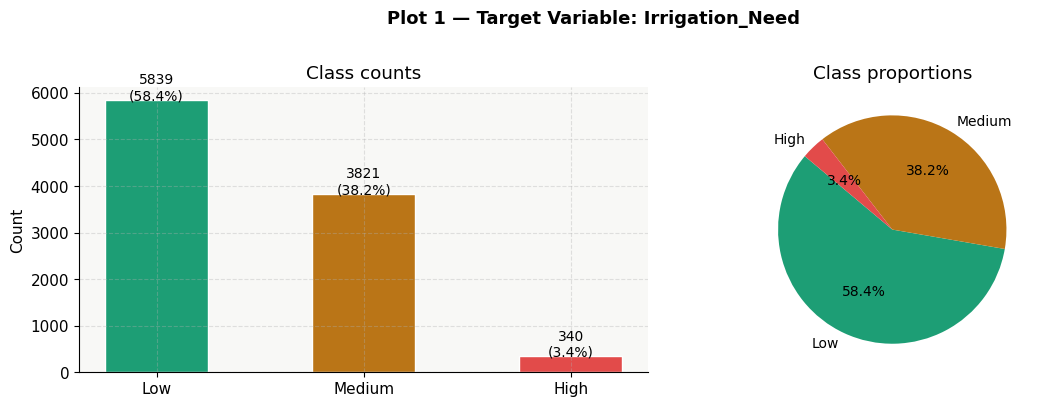

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Plot 1 — Target Variable: Irrigation_Need', fontsize=13, fontweight='bold', y=1.01)

counts = df[TARGET].value_counts()[ORDER]
pcts   = df[TARGET].value_counts(normalize=True)[ORDER] * 100

axes[0].bar(ORDER, counts, color=[PALETTE[c] for c in ORDER], width=0.5, edgecolor='white')
for i, (n, p) in enumerate(zip(counts, pcts)):
    axes[0].text(i, n + 5, f'{n}\n({p:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class counts')
axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=ORDER, colors=[PALETTE[c] for c in ORDER],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.savefig('plot1_target.png', dpi=150, bbox_inches='tight')
plt.show()

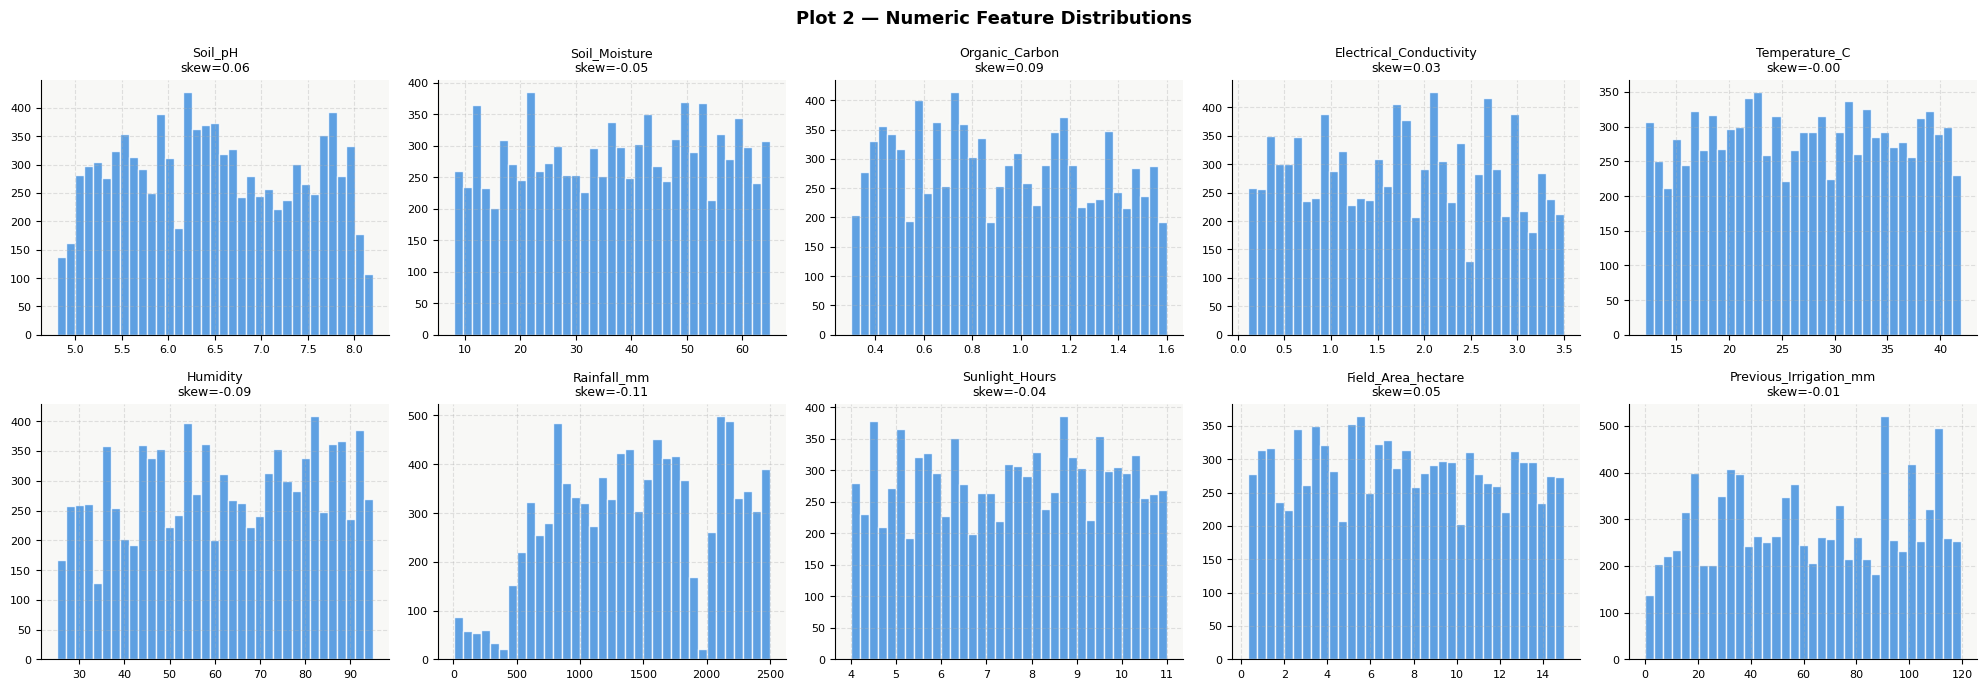


── Features with |skew| > 1 (log-transform candidates) ──


In [79]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Plot 2 — Numeric Feature Distributions', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    sk = skew(df[col].dropna())
    color = '#E24B4A' if abs(sk) > 1 else '#378ADD'
    axes[i].hist(df[col].dropna(), bins=35, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{col}\nskew={sk:.2f}', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('plot2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick print — which features need log transform
print("\n── Features with |skew| > 1 (log-transform candidates) ──")
for col in NUMERIC:
    s = skew(df[col].dropna())
    if abs(s) > 1:
        print(f"  {col:35s}  skew = {s:+.2f}")

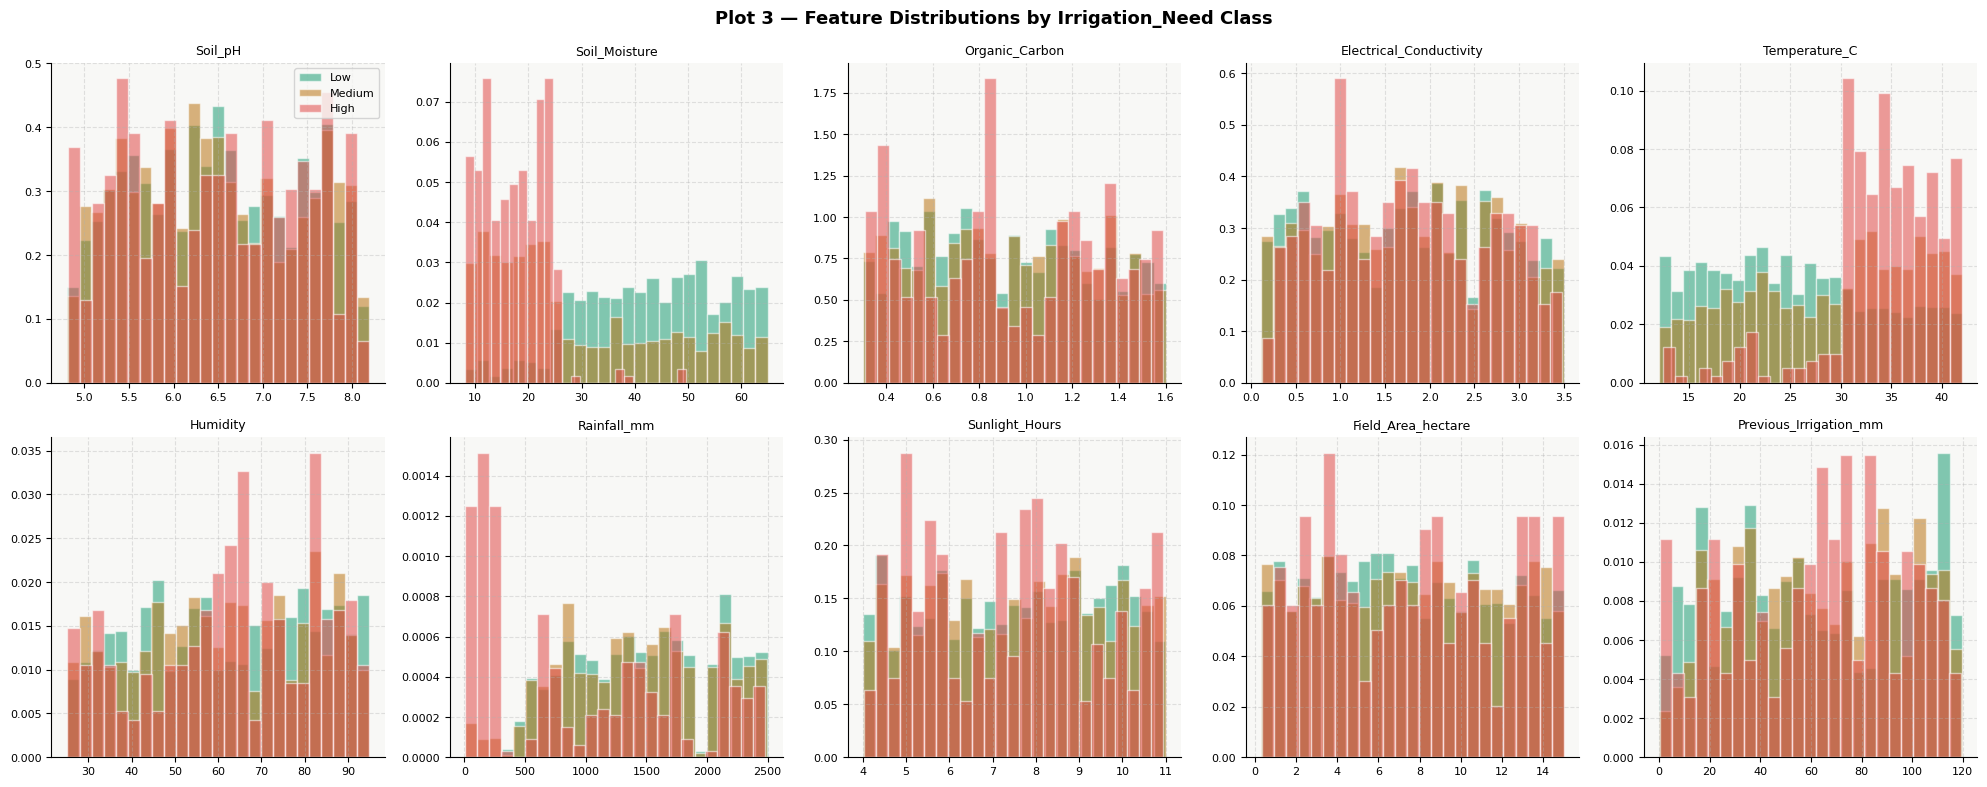

In [80]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Plot 3 — Feature Distributions by Irrigation_Need Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    for cls in ORDER:
        vals = df[df[TARGET] == cls][col].dropna()
        axes[i].hist(vals, bins=25, alpha=0.55, label=cls,
                     color=PALETTE[cls], edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot3_class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


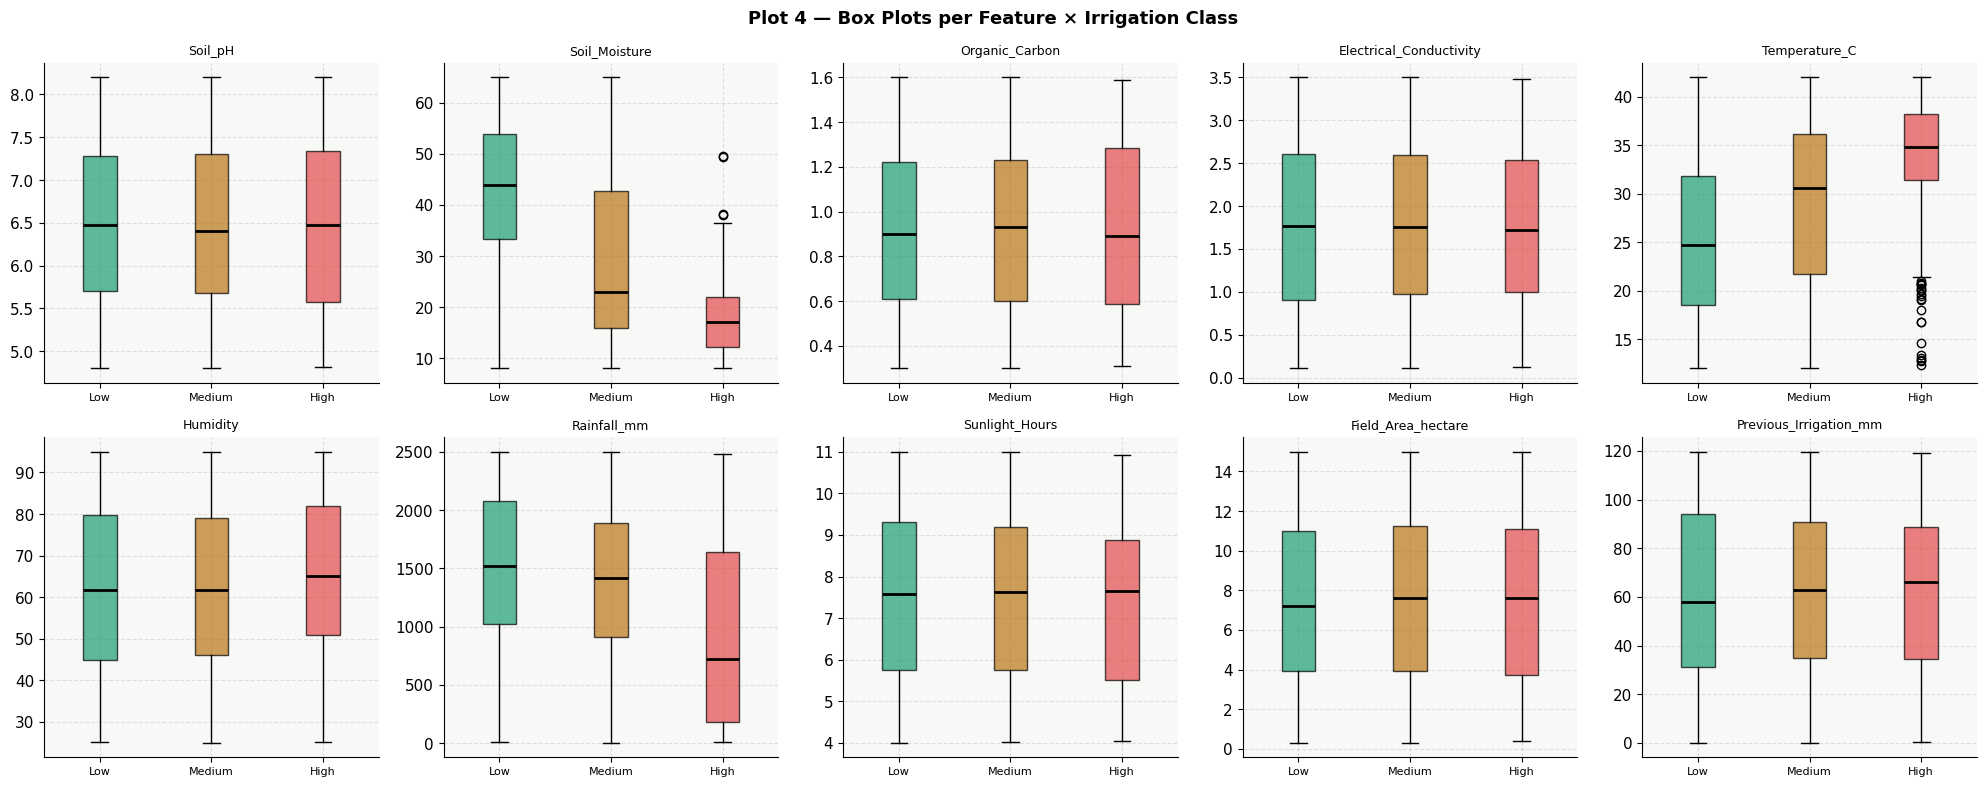


── Outlier summary (IQR method) ──
  Soil_pH                              outliers =    0  (0.0%)
  Soil_Moisture                        outliers =    0  (0.0%)
  Organic_Carbon                       outliers =    0  (0.0%)
  Electrical_Conductivity              outliers =    0  (0.0%)
  Temperature_C                        outliers =    0  (0.0%)
  Humidity                             outliers =    0  (0.0%)
  Rainfall_mm                          outliers =    0  (0.0%)
  Sunlight_Hours                       outliers =    0  (0.0%)
  Field_Area_hectare                   outliers =    0  (0.0%)
  Previous_Irrigation_mm               outliers =    0  (0.0%)


In [81]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Plot 4 — Box Plots per Feature × Irrigation Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    data_by_class = [df[df[TARGET] == cls][col].dropna() for cls in ORDER]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[cls])
        patch.set_alpha(0.7)
    axes[i].set_xticklabels(ORDER, fontsize=8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print outlier summary
print("\n── Outlier summary (IQR method) ──")
for col in NUMERIC:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:35s}  outliers = {n_out:4d}  ({pct:.1f}%)")

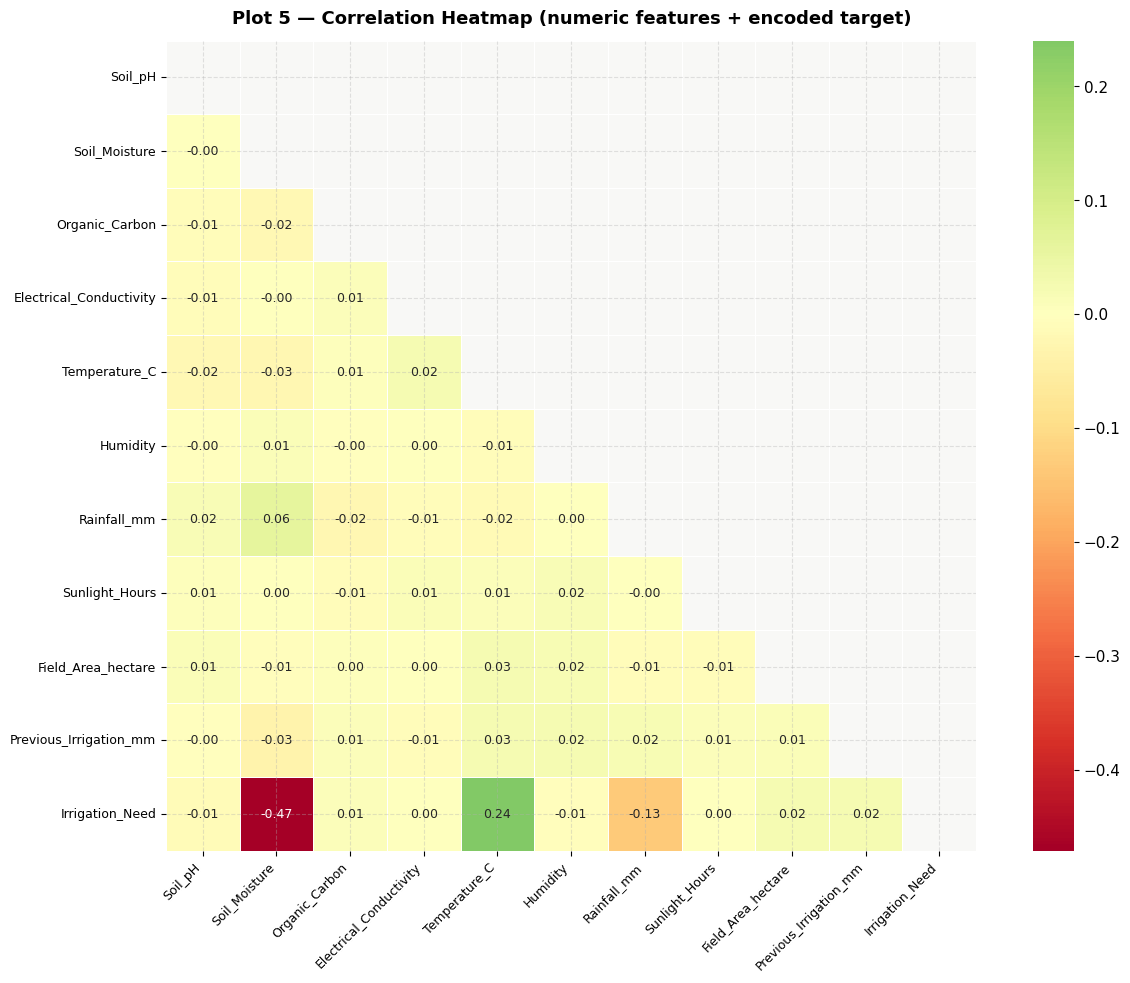

In [82]:
df_enc = df[NUMERIC + [TARGET]].copy()
df_enc[TARGET] = df_enc[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Plot 5 — Correlation Heatmap (numeric features + encoded target)', fontsize=13, fontweight='bold')

corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

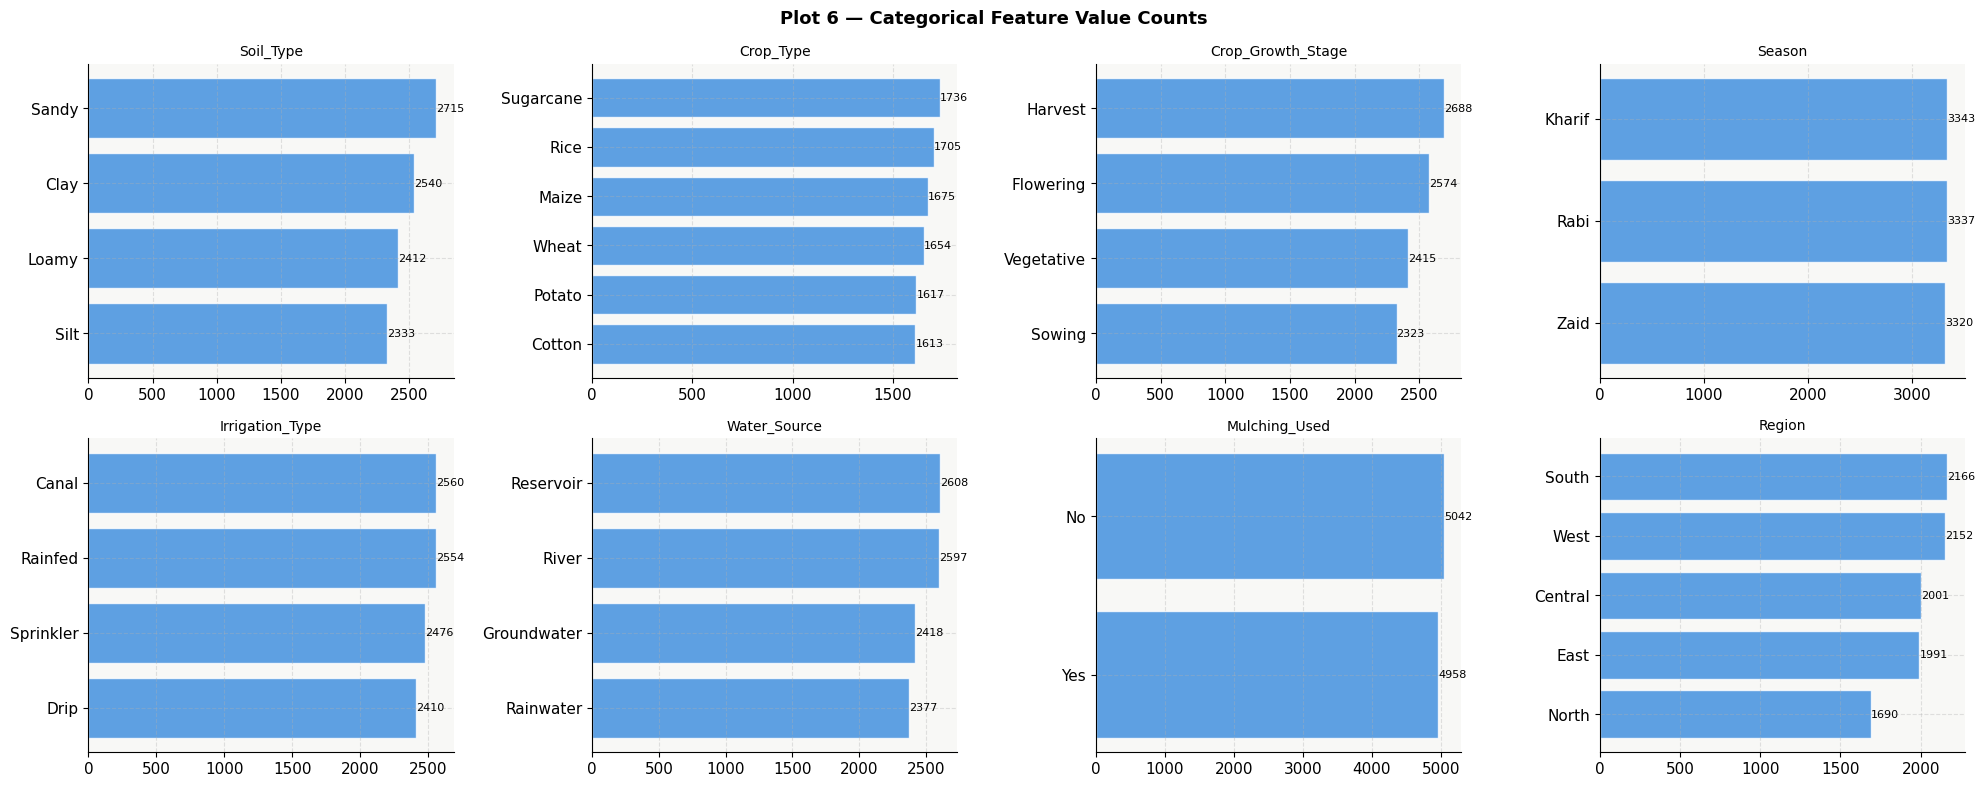

In [83]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Plot 6 — Categorical Feature Value Counts', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    vc = df[col].value_counts()
    axes[i].barh(vc.index, vc.values, color='#378ADD', alpha=0.8, edgecolor='white')
    for j, (idx, val) in enumerate(zip(vc.index, vc.values)):
        axes[i].text(val + 0.5, j, str(val), va='center', fontsize=8)
    axes[i].set_title(col, fontsize=10)
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig('plot6_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

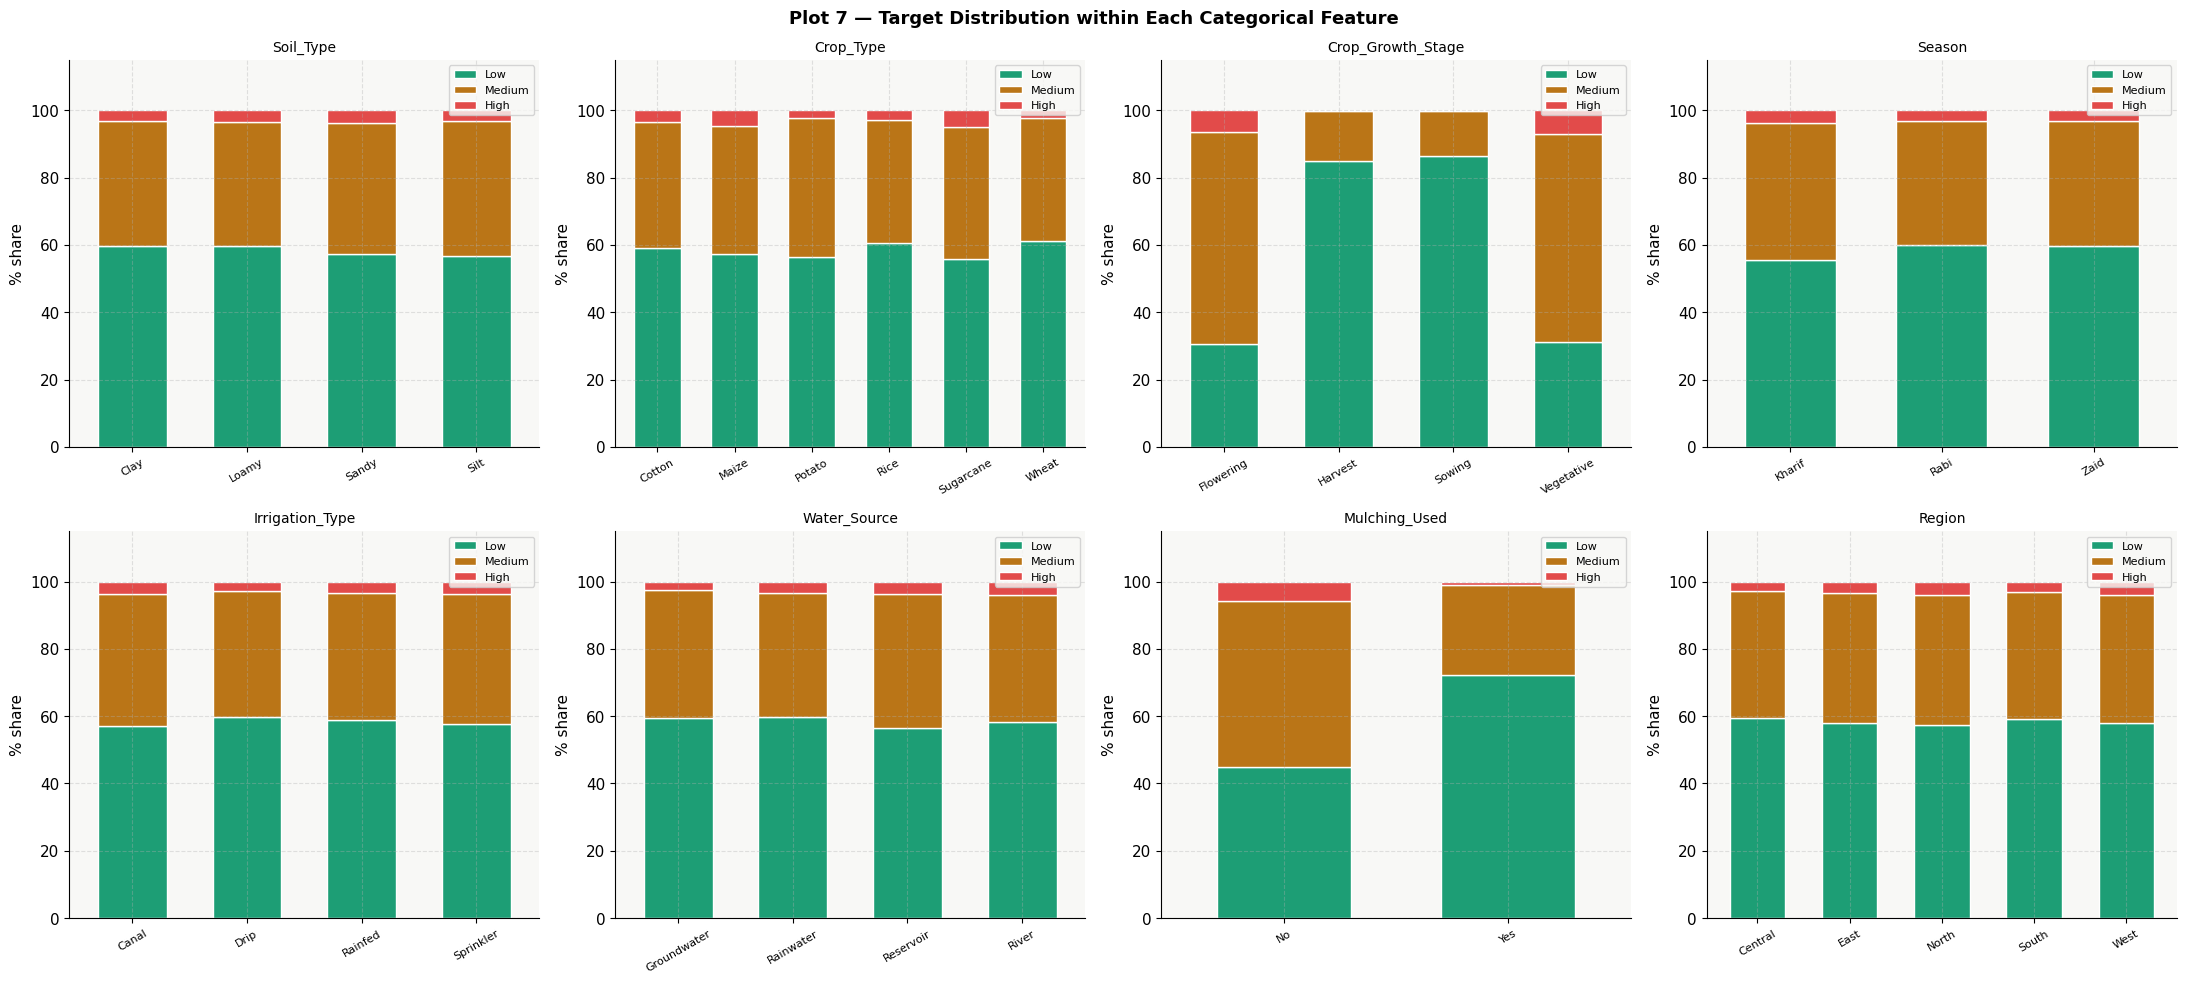

In [84]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Plot 7 — Target Distribution within Each Categorical Feature', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    ct = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    ct = ct.reindex(columns=ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[i],
                color=[PALETTE[c] for c in ORDER], edgecolor='white', width=0.6)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% share')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].legend(ORDER, fontsize=8, loc='upper right')
    axes[i].set_ylim(0, 115)

plt.tight_layout()
plt.savefig('plot7_cat_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [85]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0]

if len(missing_df) == 0:
    print("\n✓ No missing values found in dataset.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.5)))
    fig.suptitle('Plot 8 — Missing Value Analysis', fontsize=13, fontweight='bold')
    colors = ['#E24B4A' if p > 30 else '#BA7517' if p > 10 else '#1D9E75'
              for p in missing_df.values]
    ax.barh(missing_df.index, missing_df.values, color=colors, edgecolor='white')
    ax.axvline(30, color='#E24B4A', linestyle='--', alpha=0.7, label='30% threshold')
    ax.axvline(10, color='#BA7517', linestyle='--', alpha=0.7, label='10% threshold')
    ax.set_xlabel('% Missing')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plot8_missing.png', dpi=150, bbox_inches='tight')
    plt.show()

# Always print the full table
print("\n── Missing value summary ──")
print(missing_pct.to_string())


✓ No missing values found in dataset.

── Missing value summary ──
id                         0.0
Crop_Type                  0.0
Region                     0.0
Previous_Irrigation_mm     0.0
Mulching_Used              0.0
Field_Area_hectare         0.0
Water_Source               0.0
Irrigation_Type            0.0
Season                     0.0
Crop_Growth_Stage          0.0
Wind_Speed_kmh             0.0
Soil_Type                  0.0
Sunlight_Hours             0.0
Rainfall_mm                0.0
Humidity                   0.0
Temperature_C              0.0
Electrical_Conductivity    0.0
Organic_Carbon             0.0
Soil_Moisture              0.0
Soil_pH                    0.0
Irrigation_Need            0.0


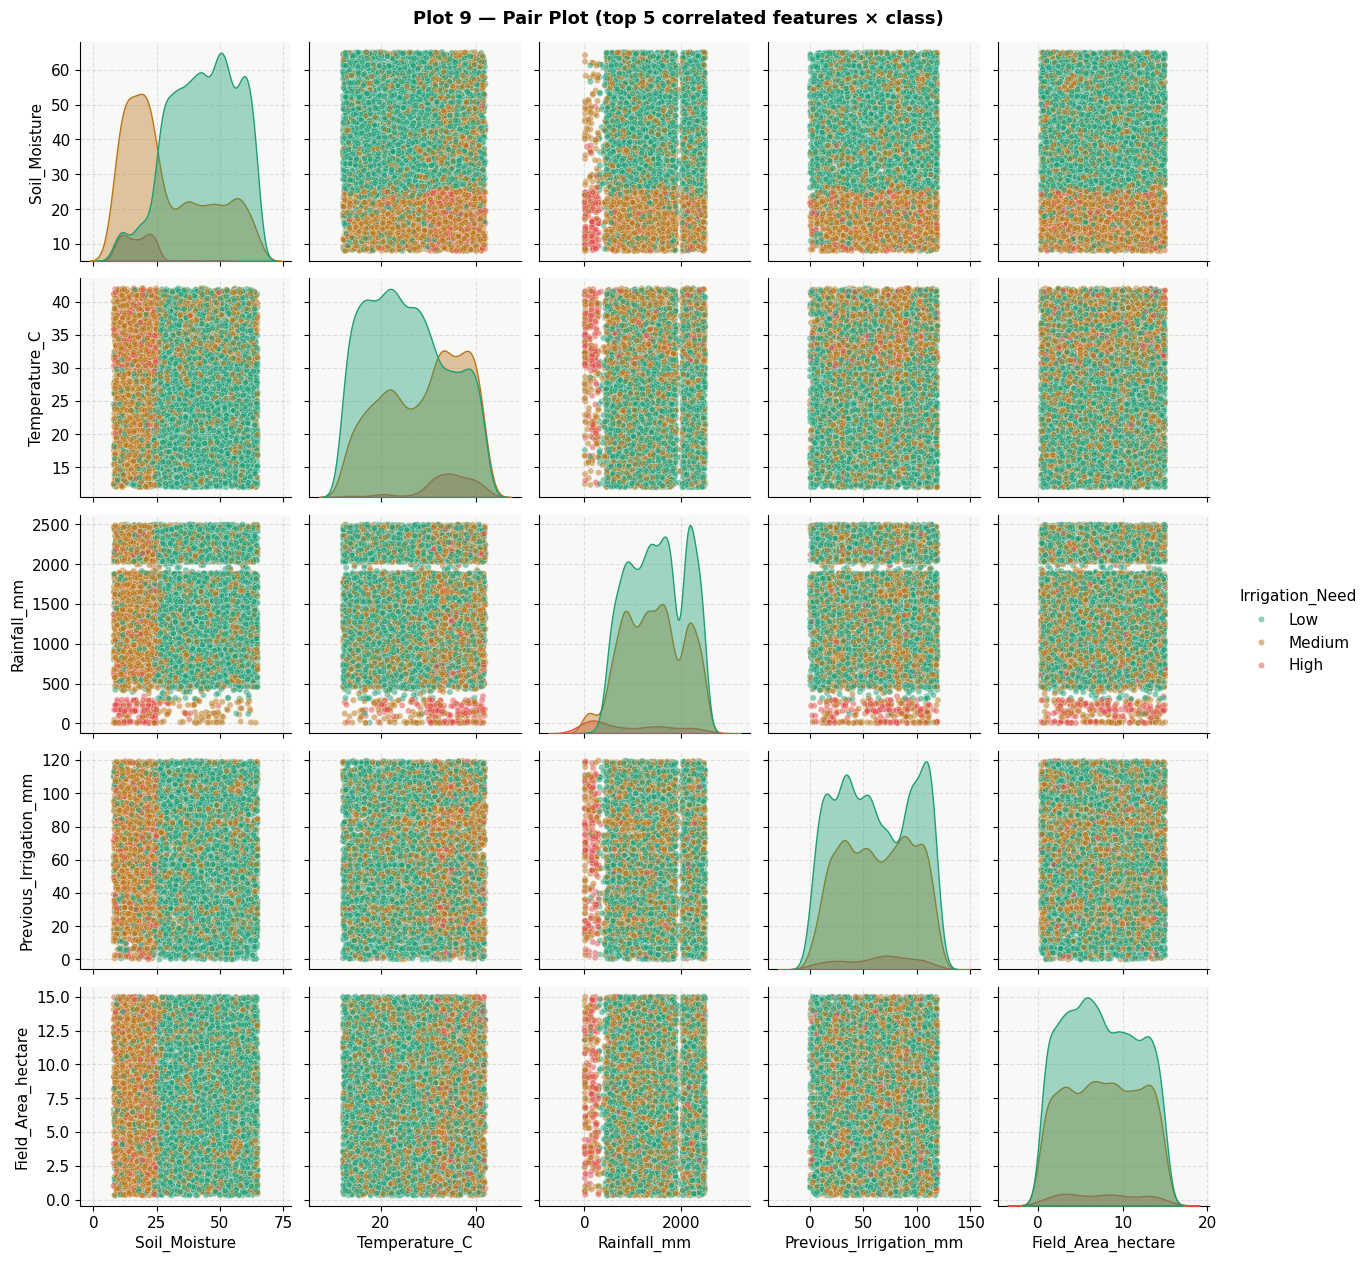

In [86]:
# Use top 5 correlated features with target for clarity
df_enc_tmp = df[NUMERIC].copy()
target_enc = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
correlations_with_target = df_enc_tmp.corrwith(target_enc).abs().sort_values(ascending=False)
top5 = correlations_with_target.head(5).index.tolist()

pair_df = df[top5 + [TARGET]].copy()
g = sns.pairplot(pair_df, hue=TARGET, hue_order=ORDER,
                 palette=PALETTE, diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kws={'fill': True, 'alpha': 0.4})
g.fig.suptitle('Plot 9 — Pair Plot (top 5 correlated features × class)', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('plot9_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\itspr\AppData\Local\Temp\ipykernel_22984\1692261657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
C:\Users\itspr\AppData\Local\Temp\ipykernel_22984\1692261657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
C:\Users\itspr\AppData\Local\Temp\ipykernel_22984\1692261657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
C:\Users\itspr\AppData\Local\Temp\ipykernel_22984\1692261657.py:6: FutureWarning: 

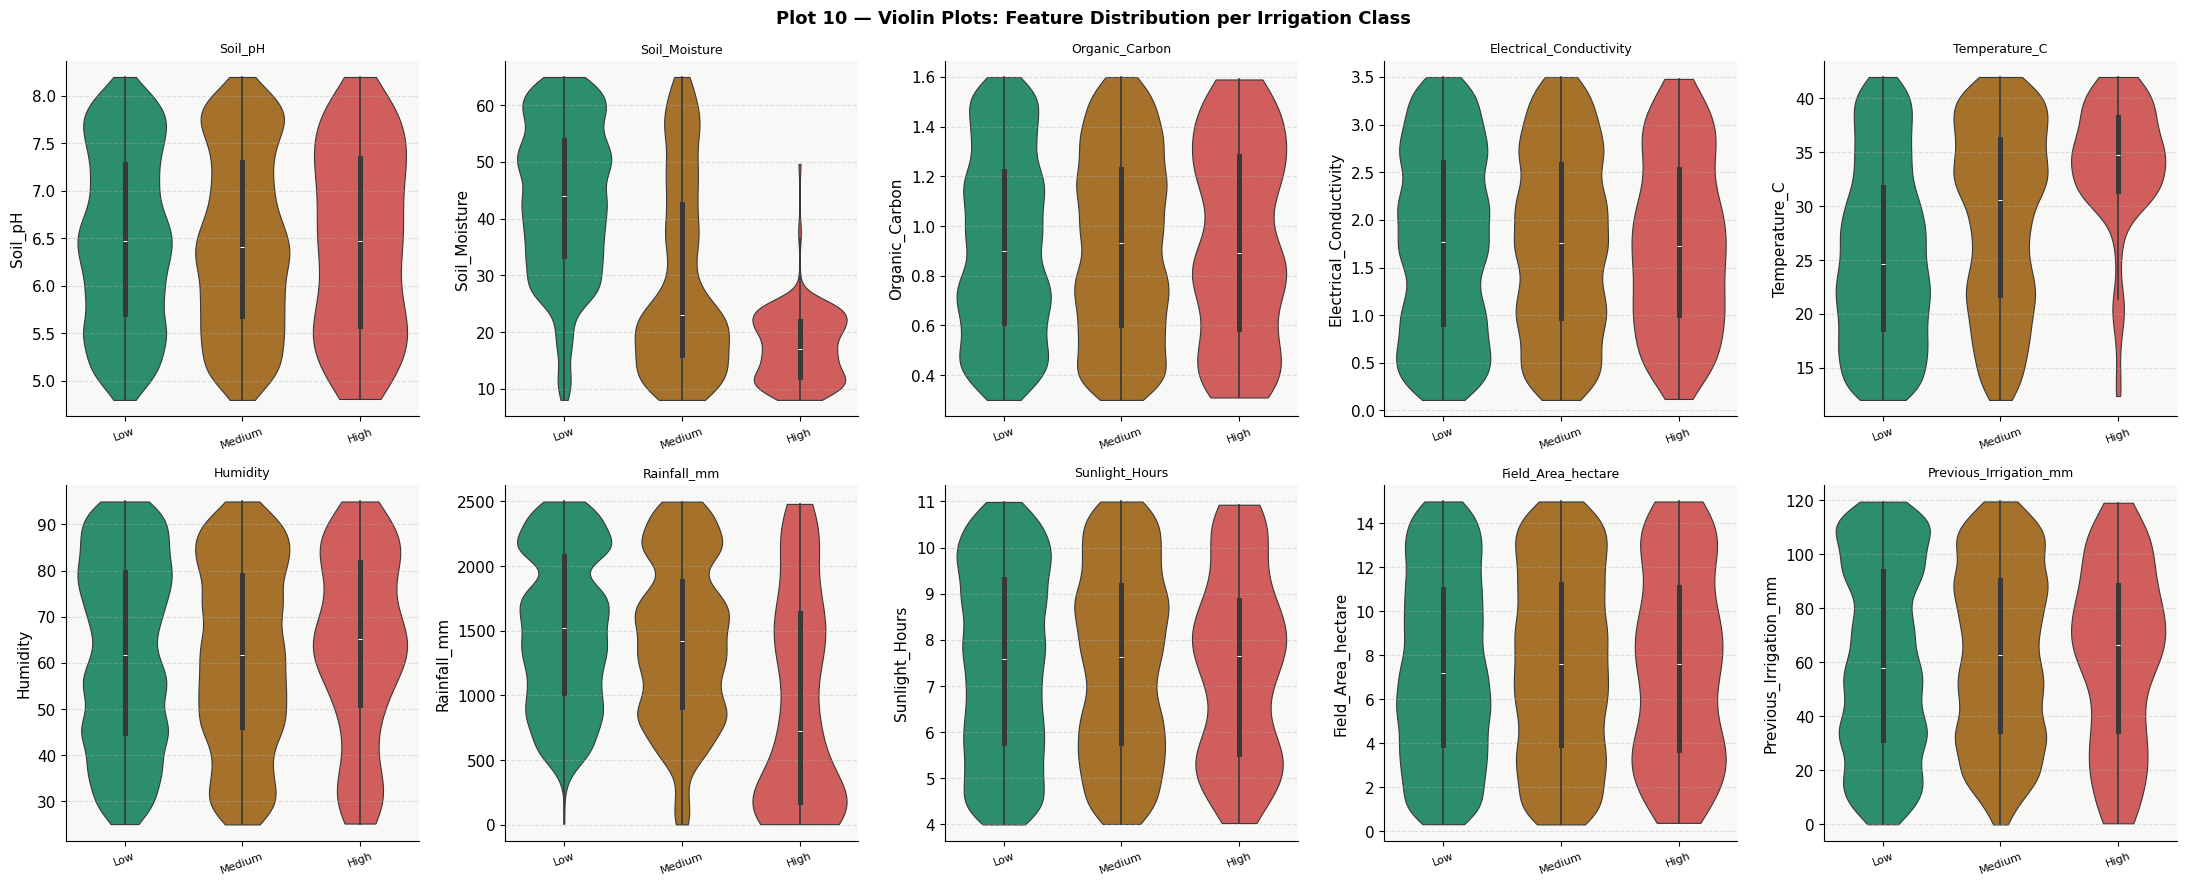

In [87]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Plot 10 — Violin Plots: Feature Distribution per Irrigation Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
                   palette=PALETTE, ax=axes[i], inner='box',
                   cut=0, linewidth=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20, labelsize=8)

plt.tight_layout()
plt.savefig('plot10_violin.png', dpi=150, bbox_inches='tight')
plt.show()

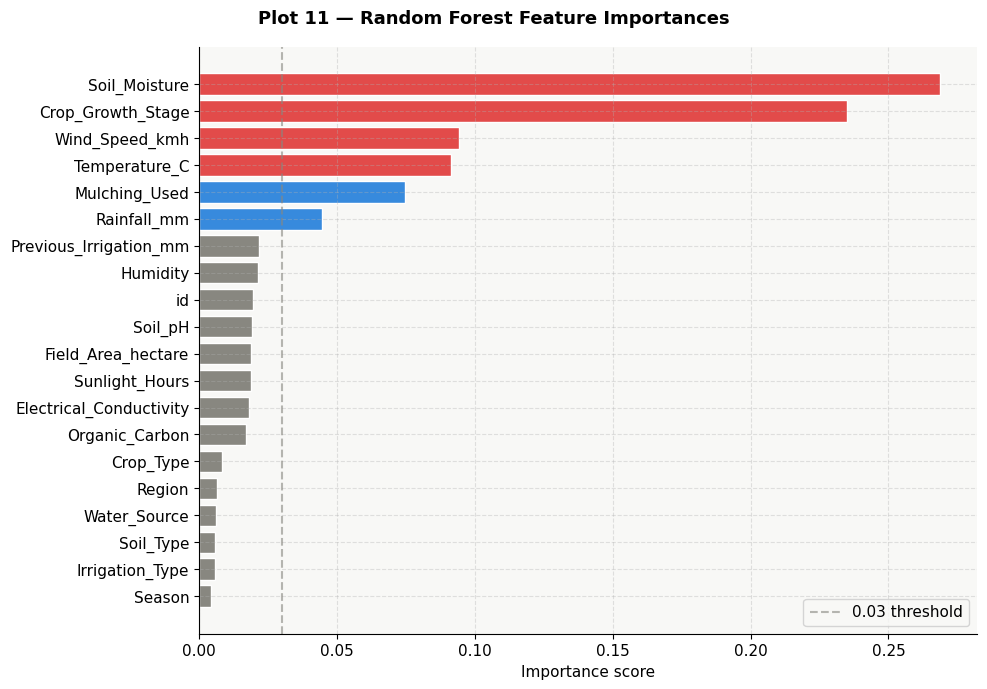


── Feature importances (descending) ──
Soil_Moisture              0.268697
Crop_Growth_Stage          0.234938
Wind_Speed_kmh             0.094380
Temperature_C              0.091261
Mulching_Used              0.074660
Rainfall_mm                0.044588
Previous_Irrigation_mm     0.021884
Humidity                   0.021194
id                         0.019477
Soil_pH                    0.019096
Field_Area_hectare         0.018963
Sunlight_Hours             0.018760
Electrical_Conductivity    0.018031
Organic_Carbon             0.017186
Crop_Type                  0.008204
Region                     0.006514
Water_Source               0.006001
Soil_Type                  0.005886
Irrigation_Type            0.005808
Season                     0.004472


In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_rf = df.copy()
for col in CATEGORICAL:
    df_rf[col] = LabelEncoder().fit_transform(df_rf[col].astype(str))
df_rf[TARGET] = LabelEncoder().fit_transform(df_rf[TARGET])
df_rf = df_rf.fillna(df_rf.median(numeric_only=True))

X = df_rf.drop(columns=[TARGET])
y = df_rf[TARGET]

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X, y)

fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(fi) * 0.35)))
fig.suptitle('Plot 11 — Random Forest Feature Importances', fontsize=13, fontweight='bold')

colors = ['#E24B4A' if v > 0.08 else '#378ADD' if v > 0.03 else '#888780' for v in fi.values]
ax.barh(fi.index, fi.values, color=colors, edgecolor='white')
ax.axvline(0.03, color='#888780', linestyle='--', alpha=0.6, label='0.03 threshold')
ax.set_xlabel('Importance score')
ax.legend()

plt.tight_layout()
plt.savefig('plot11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature importances (descending) ──")
print(fi.sort_values(ascending=False).to_string())

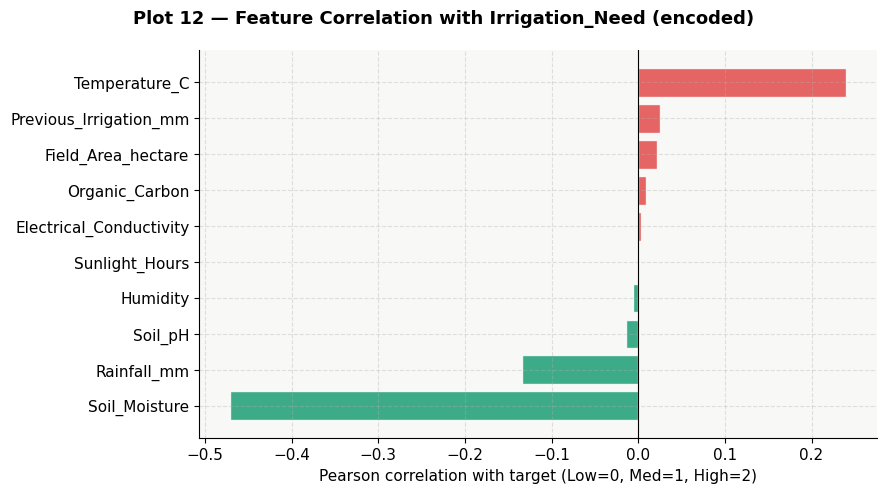

In [89]:
target_enc = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
corrs = df[NUMERIC].corrwith(target_enc).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Plot 12 — Feature Correlation with Irrigation_Need (encoded)', fontsize=13, fontweight='bold')

colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with target (Low=0, Med=1, High=2)')

plt.tight_layout()
plt.savefig('plot12_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


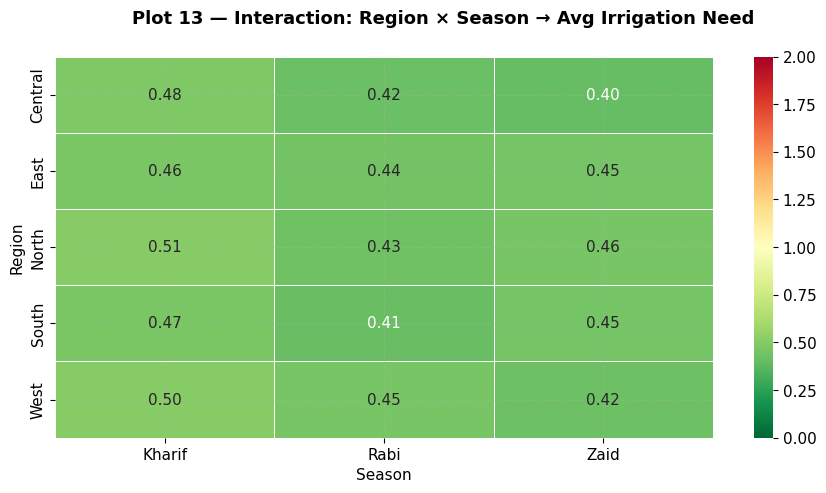

In [90]:
target_enc_series = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
pivot = df.copy()
pivot['target_enc'] = target_enc_series
heat = pivot.groupby(['Region', 'Season'])['target_enc'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Plot 13 — Interaction: Region × Season → Avg Irrigation Need', fontsize=13, fontweight='bold')
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=2)
ax.set_xlabel('Season')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('plot13_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

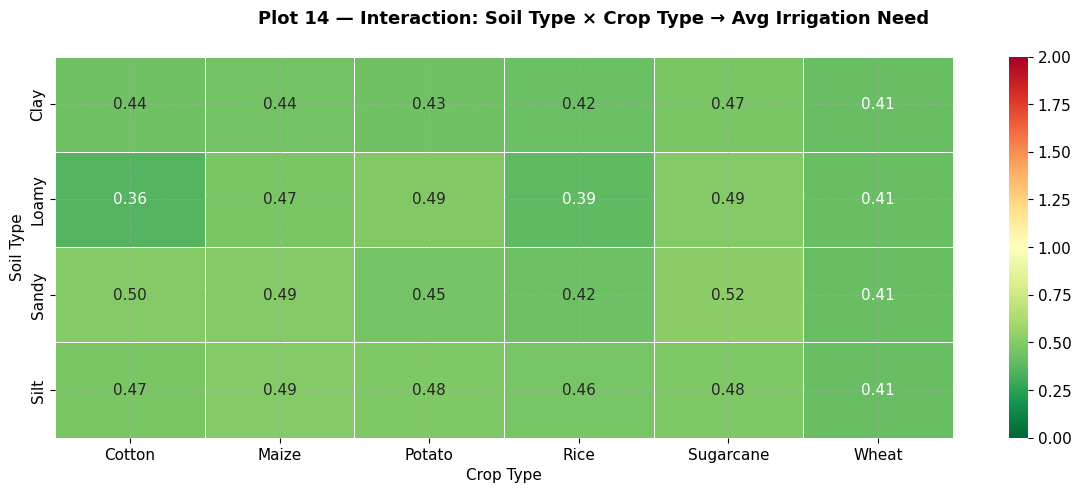

In [91]:
pivot2 = df.copy()
pivot2['target_enc'] = target_enc_series
heat2 = pivot2.groupby(['Soil_Type', 'Crop_Type'])['target_enc'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Plot 14 — Interaction: Soil Type × Crop Type → Avg Irrigation Need', fontsize=13, fontweight='bold')
sns.heatmap(heat2, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=2)
ax.set_xlabel('Crop Type')
ax.set_ylabel('Soil Type')
plt.tight_layout()
plt.savefig('plot14_soil_crop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [92]:
# import shap

# # Use the random forest from Plot 11 (or replace with your best model)
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X)

# # For multi-class, shap_values is a list [class0, class1, class2]
# # Plot for class 'High' (index 2 after LabelEncoding)
# plt.figure(figsize=(10, 7))
# shap.summary_plot(shap_values[2], X, plot_type='dot',
#                   show=False, max_display=15)
# plt.title('Plot 15 — SHAP Summary (class: High irrigation need)', fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.savefig('plot15_shap.png', dpi=150, bbox_inches='tight')
# plt.show()

In [93]:
print("\n" + "="*60)
print("  EDA COMPLETE — KEY DECISIONS CHECKLIST")
print("="*60)
print(f"  Rows          : {len(df):,}")
print(f"  Columns       : {df.shape[1]}")
print(f"  Numeric feats : {len(NUMERIC)}")
print(f"  Categorical   : {len(CATEGORICAL)}")
print(f"\n  Target distribution:")
for cls in ORDER:
    n = (df[TARGET] == cls).sum()
    print(f"    {cls:8s}: {n:5d}  ({n/len(df)*100:.1f}%)")
print(f"\n  Missing values: {df.isnull().sum().sum()} total cells")
print(f"\n  High-skew features (|skew|>1):")
for col in NUMERIC:
    s = skew(df[col].dropna())
    if abs(s) > 1:
        print(f"    {col} → log1p transform recommended")
print("\n" + "="*60)


  EDA COMPLETE — KEY DECISIONS CHECKLIST
  Rows          : 10,000
  Columns       : 21
  Numeric feats : 10
  Categorical   : 8

  Target distribution:
    Low     :  5839  (58.4%)
    Medium  :  3821  (38.2%)
    High    :   340  (3.4%)

  Missing values: 0 total cells

  High-skew features (|skew|>1):



## Feature Engineering

In [94]:
mapper = {
    'Low' : 0,
    'Medium': 1,
    'High': 2
}
train_df['Irrigation_Need'] = train_df['Irrigation_Need'].map(mapper)

print(train_df['Irrigation_Need'].unique())

[0 1 2]


In [95]:
train_df.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [96]:
train_df['Season'].unique() # we have to give them some different weight because they need different amount of irrigation

array(['Zaid', 'Kharif', 'Rabi'], dtype=object)

In [97]:
# season_mapper = {
#     'Zaid': 1,      # needs least irrigation
#     'Rabi': 2.5,      # needs more irrigation than Zaid
#     'Kharif': 5     # needs the most irrigation much more than Rabi
# }
# train_df['Season'] = train_df['Season'].map(season_mapper)

In [98]:
train_df['Soil_Moisture_X_Temperature'] = train_df['Soil_Moisture'] * train_df['Temperature_C']
train_df['Humidity_X_Rainfall_mm'] = train_df['Humidity'] + train_df['Rainfall_mm']

In [99]:
train_df.select_dtypes(include='number').corr()['Irrigation_Need']

id                            -0.000903
Soil_pH                        0.000150
Soil_Moisture                 -0.455482
Organic_Carbon                 0.006451
Electrical_Conductivity        0.010785
Temperature_C                  0.252867
Humidity                      -0.021870
Rainfall_mm                   -0.111478
Sunlight_Hours                -0.000313
Wind_Speed_kmh                 0.258170
Field_Area_hectare             0.017699
Previous_Irrigation_mm         0.019637
Irrigation_Need                1.000000
Soil_Moisture_X_Temperature   -0.228574
Humidity_X_Rainfall_mm        -0.112121
Name: Irrigation_Need, dtype: float64

In [100]:
prnt()

NameError: name 'prnt' is not defined

### Filtering Numerical and Categorcial Columns for Scaling and Categorical Columns

In [ ]:
train_df = train_df.drop('id', axis=1)

test_id = test_df['id']
test_df = test_df.drop('id', axis=1)

test_df.size

5130000

In [ ]:
print('All columns:\n{train_df.columns}')

# Selecting columns for train_df
train_num_cols = train_df.select_dtypes(include='number').columns.to_list()
train_num_cols.remove('Irrigation_Need')
print(f'\nNumerical Columns:\n{train_num_cols}')

train_cat_cols = train_df.select_dtypes(include='object').columns.to_list()
print(f'\nCategorical Columns:\n{train_cat_cols}')

# Selecting columns for test_df
test_num_cols = test_df.select_dtypes(include='number').columns.to_list()
print(f'\nNumerical Columns:\n{test_num_cols}')

test_cat_cols = test_df.select_dtypes(include='object').columns.to_list()
print(f'\nCategorical Columns:\n{test_cat_cols}')

All columns:
{train_df.columns}

Numerical Columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Categorical Columns:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

Numerical Columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Categorical Columns:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


## Scaling Dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(train_df[train_num_cols])

In [ ]:
train_df[train_num_cols] = scaler.transform(train_df[train_num_cols])
test_df[test_num_cols] = scaler.transform(test_df[test_num_cols])

In [ ]:
train_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,0.035294,0.431304,0.546154,0.867647,0.100333,0.365909,0.290324,0.271429,0.835385,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.035374,No,0.934734,East,0
1,Clay,0.670588,0.852957,0.107692,0.558824,0.364000,0.612373,0.394221,0.425714,0.148205,Wheat,Vegetative,Kharif,Rainfed,River,0.338095,Yes,0.392932,South,0
2,Clay,0.261765,0.345850,0.392308,0.802941,0.499000,0.960423,0.880771,0.292857,0.171795,Rice,Vegetative,Kharif,Sprinkler,Reservoir,0.540136,Yes,0.919897,North,0
3,Sandy,0.250000,0.093350,0.792308,0.226471,0.044000,0.522503,0.542930,0.731429,0.092821,Wheat,Flowering,Kharif,Canal,River,0.545578,Yes,0.448696,South,1
4,Clay,0.929412,0.897350,0.061538,0.252941,0.274000,0.944564,0.615298,0.421429,0.689231,Wheat,Sowing,Rabi,Canal,River,0.480952,No,0.776611,South,0


In [ ]:
test_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Silt,0.458824,0.319179,0.223077,0.797059,0.194333,0.074868,0.613369,0.200000,0.128205,Maize,Sowing,Rabi,Canal,River,0.904082,Yes,0.395599,West
1,Clay,0.314706,0.032988,0.676923,0.929412,0.306000,0.758251,0.230332,0.460000,0.788718,Cotton,Sowing,Rabi,Drip,Reservoir,0.395918,Yes,0.470201,South
2,Sandy,0.417647,0.325496,0.507692,0.220588,0.495667,0.505072,0.218028,0.775714,0.109231,Wheat,Sowing,Kharif,Sprinkler,Reservoir,0.191156,Yes,0.166542,East
3,Clay,0.847059,0.799789,0.407692,0.132353,0.991333,0.157880,0.484394,0.384286,0.069744,Maize,Harvest,Rabi,Canal,Groundwater,0.134014,No,0.858298,North
4,Loamy,0.126471,0.895245,0.184615,0.591176,0.969333,0.392485,0.528758,0.015714,0.267179,Cotton,Sowing,Kharif,Canal,Groundwater,0.822449,Yes,0.110944,Central


## Imputing the Categorical Columns

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_df[train_cat_cols])

In [ ]:
encoded_cols = encoder.get_feature_names_out().tolist()
encoded_cols, type(encoded_cols)

(['Soil_Type_Clay',
  'Soil_Type_Loamy',
  'Soil_Type_Sandy',
  'Soil_Type_Silt',
  'Crop_Type_Cotton',
  'Crop_Type_Maize',
  'Crop_Type_Potato',
  'Crop_Type_Rice',
  'Crop_Type_Sugarcane',
  'Crop_Type_Wheat',
  'Crop_Growth_Stage_Flowering',
  'Crop_Growth_Stage_Harvest',
  'Crop_Growth_Stage_Sowing',
  'Crop_Growth_Stage_Vegetative',
  'Season_Kharif',
  'Season_Rabi',
  'Season_Zaid',
  'Irrigation_Type_Canal',
  'Irrigation_Type_Drip',
  'Irrigation_Type_Rainfed',
  'Irrigation_Type_Sprinkler',
  'Water_Source_Groundwater',
  'Water_Source_Rainwater',
  'Water_Source_Reservoir',
  'Water_Source_River',
  'Mulching_Used_No',
  'Mulching_Used_Yes',
  'Region_Central',
  'Region_East',
  'Region_North',
  'Region_South',
  'Region_West'],
 list)

In [ ]:
train_df[encoded_cols] = encoder.transform(train_df[train_cat_cols])
test_df[encoded_cols] = encoder.transform(test_df[test_cat_cols])

In [ ]:
train_df.columns, test_df.columns

(Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
        'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
        'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
        'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
        'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
        'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy',
        'Soil_Type_Silt', 'Crop_Type_Cotton', 'Crop_Type_Maize',
        'Crop_Type_Potato', 'Crop_Type_Rice', 'Crop_Type_Sugarcane',
        'Crop_Type_Wheat', 'Crop_Growth_Stage_Flowering',
        'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing',
        'Crop_Growth_Stage_Vegetative', 'Season_Kharif', 'Season_Rabi',
        'Season_Zaid', 'Irrigation_Type_Canal', 'Irrigation_Type_Drip',
        'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
        'Water_Source_Groundwater', 'Water_Source_Rainwater',
        'Water_Source_Reservoi

In [ ]:
for col in train_df.columns:
    print(f'{col}: {train_df[col].dtype}')

Soil_Type: object
Soil_pH: float64
Soil_Moisture: float64
Organic_Carbon: float64
Electrical_Conductivity: float64
Temperature_C: float64
Humidity: float64
Rainfall_mm: float64
Sunlight_Hours: float64
Wind_Speed_kmh: float64
Crop_Type: object
Crop_Growth_Stage: object
Season: object
Irrigation_Type: object
Water_Source: object
Field_Area_hectare: float64
Mulching_Used: object
Previous_Irrigation_mm: float64
Region: object
Irrigation_Need: int64
Soil_Type_Clay: float64
Soil_Type_Loamy: float64
Soil_Type_Sandy: float64
Soil_Type_Silt: float64
Crop_Type_Cotton: float64
Crop_Type_Maize: float64
Crop_Type_Potato: float64
Crop_Type_Rice: float64
Crop_Type_Sugarcane: float64
Crop_Type_Wheat: float64
Crop_Growth_Stage_Flowering: float64
Crop_Growth_Stage_Harvest: float64
Crop_Growth_Stage_Sowing: float64
Crop_Growth_Stage_Vegetative: float64
Season_Kharif: float64
Season_Rabi: float64
Season_Zaid: float64
Irrigation_Type_Canal: float64
Irrigation_Type_Drip: float64
Irrigation_Type_Rainfed: flo

### Final training and test datasets

In [ ]:
input_cols = train_num_cols + encoded_cols
target_col = 'Irrigation_Need'

In [ ]:
input_df = train_df[train_num_cols + encoded_cols]
test_df = test_df[test_num_cols + encoded_cols]

In [ ]:
input_df.columns, test_df.columns

(Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
        'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
        'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
        'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy',
        'Soil_Type_Silt', 'Crop_Type_Cotton', 'Crop_Type_Maize',
        'Crop_Type_Potato', 'Crop_Type_Rice', 'Crop_Type_Sugarcane',
        'Crop_Type_Wheat', 'Crop_Growth_Stage_Flowering',
        'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing',
        'Crop_Growth_Stage_Vegetative', 'Season_Kharif', 'Season_Rabi',
        'Season_Zaid', 'Irrigation_Type_Canal', 'Irrigation_Type_Drip',
        'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
        'Water_Source_Groundwater', 'Water_Source_Rainwater',
        'Water_Source_Reservoir', 'Water_Source_River', 'Mulching_Used_No',
        'Mulching_Used_Yes', 'Region_Central', 'Region_East', 'Region_North',
        'Region_South', 'Regio

In [ ]:
test_df.size

11610000

## Train/Val Split and Test Input and Target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val , Y_train, Y_val = train_test_split(input_df[input_cols],
                                                   train_df[target_col],
                                                   test_size=0.2,
                                                   random_state=231)

## Training Models

In [ ]:
from sklearn.metrics import accuracy_score

### LightGBM Model

In [ ]:
import lightgbm

In [ ]:
lgbm = lightgbm.LGBMClassifier()

In [ ]:
lgbm.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 43
[LightGBM] [Info] Start training from score -0.532018
[LightGBM] [Info] Start training from score -0.969633
[LightGBM] [Info] Start training from score -3.400424


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
train_pred = lgbm.predict(X_train)
val_pred = lgbm.predict(X_val)

In [ ]:
train_acc = accuracy_score(Y_train, train_pred)
val_acc = accuracy_score(Y_val, val_pred)

print(train_acc)
print(val_acc)

0.9848174603174603
0.9838650793650794


# XGBoost

In [ ]:
import xgboost

In [ ]:
xgbc = xgboost.XGBClassifier().fit(X_train, Y_train)

KeyboardInterrupt: 

In [ ]:
train_pred = xgbc.predict(X_train)
val_pred = xgbc.predict(X_val)

In [ ]:
train_acc = accuracy_score(Y_train, train_pred)
val_acc = accuracy_score(Y_val, val_pred)

print(train_acc)
print(val_acc)

0.987077380952381
0.9839920634920635


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression().fit(X_train, Y_train)

In [ ]:
train_pred = lr.predict(X_train)
val_pred = lr.predict(X_val)

In [ ]:
train_acc = accuracy_score(Y_train, train_pred)
val_acc = accuracy_score(Y_val, val_pred)

print(train_acc)
print(val_acc)

0.876470238095238
0.8753650793650793


## Predicting the test set

In [ ]:
test_pred = xgbc.predict(test_df)

In [ ]:
test_pred = pd.DataFrame(test_pred)

In [ ]:
print(f'Final predictions shape: {test_pred.shape}')
print(test_pred[:20])

Final predictions shape: (270000, 1)
    0
0   0
1   0
2   0
3   0
4   0
5   1
6   0
7   1
8   1
9   0
10  0
11  0
12  1
13  0
14  1
15  1
16  0
17  1
18  1
19  1


In [ ]:
test_id.head()

0    630000
1    630001
2    630002
3    630003
4    630004
Name: id, dtype: int64

In [ ]:
test_pred.columns

RangeIndex(start=0, stop=1, step=1)

In [ ]:
test_pred[0].unique()

array([0, 1, 2], dtype=int64)

In [ ]:
mapper = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}
test_pred[0] = test_pred[0].map(mapper)

In [ ]:
test_id = test_id.reset_index(drop = True)
min_id = test_id.min()
max_id = test_id.max()

print(min_id, max_id)

630000 899999


In [ ]:
max_id - min_id

269999

In [ ]:
test_pred.size

270000

In [ ]:
submission = pd.DataFrame({
    'id': test_id.reset_index(drop=True),
    'Irrigation_Need': test_pred[0].reset_index(drop=True)
})

In [ ]:
submission.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [ ]:
submission.tail()

,id,Irrigation_Need
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low
269999,899999,Medium


In [ ]:
submission.to_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Codes\submission_files\Irrigation_Prediction_Submission1.csv', index=False)